# Q3: Phân tích hoạt động đại lý — RFM + churn prediction

Câu hỏi kinh doanh: đại lý nào có nguy cơ churn cao và xác suất đặt hàng lại trong Q2/2026 là bao nhiêu?

Phương pháp: RFM rule-based scoring → Logistic Regression dự báo churn → BG-NBD ước tính CLV 90 ngày.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')
print('Core imports OK')

Core imports OK


In [2]:
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date'] = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
df['seg2_group'] = df['product_code'].str[6:9]
df['year_month'] = df['order_date'].dt.to_period('M')

df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
print(f'Dữ liệu sạch: {len(df):,} dòng')
print(f'Số đại lý: {df["customer_code"].nunique()}')

Dữ liệu sạch: 17,031 dòng
Số đại lý: 702


In [3]:
REFERENCE_DATE = pd.Timestamp('2026-03-01')

rfm = df.groupby('customer_code').agg(
    recency=('order_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('so_number', 'nunique'),
    monetary=('line_total', 'sum')
).reset_index()

dealer_names = df.groupby('customer_code')['customer_name'].first().reset_index()
rfm = rfm.merge(dealer_names, on='customer_code', how='left')

print(f'RFM computed cho {len(rfm)} đại lý')
print(rfm[['recency','frequency','monetary']].describe().round(0))

RFM computed cho 702 đại lý
       recency  frequency      monetary
count    702.0      702.0  7.020000e+02
mean     157.0        2.0  9.777936e+07
std      165.0        4.0  2.667727e+08
min        1.0        1.0  1.472222e+06
25%       17.0        1.0  2.409694e+07
50%       34.0        1.0  4.504611e+07
75%      341.0        2.0  8.854000e+07
max      419.0       67.0  4.978860e+09


In [4]:
def rfm_quintile_score(x, col, ascending=True):
    try:
        q = pd.qcut(x[col], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    except Exception:
        q = pd.cut(x[col], bins=5, labels=[1, 2, 3, 4, 5])
    if not ascending:
        q = 6 - q.astype(int)
        return q
    return q.astype(int)

rfm['R_score'] = rfm_quintile_score(rfm, 'recency', ascending=False)
rfm['F_score'] = rfm_quintile_score(rfm, 'frequency', ascending=True)
rfm['M_score'] = rfm_quintile_score(rfm, 'monetary', ascending=True)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('RFM score distribution:')
print(rfm[['R_score','F_score','M_score','RFM_total']].describe().round(1))

RFM score distribution:
       R_score  F_score  M_score  RFM_total
count    702.0    702.0    702.0      702.0
mean       3.1      1.0      3.0        7.1
std        1.4      0.3      1.4        2.4
min        1.0      1.0      1.0        3.0
25%        2.0      1.0      2.0        5.0
50%        3.0      1.0      3.0        7.0
75%        4.0      1.0      4.0        9.0
max        5.0      5.0      5.0       15.0


In [5]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    total = r + f + m
    if total >= 12:
        return 'Champions'
    elif total >= 9 and r >= 4:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r == 1:
        return 'Lost'
    else:
        return 'Potential'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
seg_counts = rfm['segment'].value_counts()
print('Phân đoạn đại lý:')
print(seg_counts)

Phân đoạn đại lý:
segment
Potential    282
Loyal        181
Lost         135
New          100
Champions      4
Name: count, dtype: int64


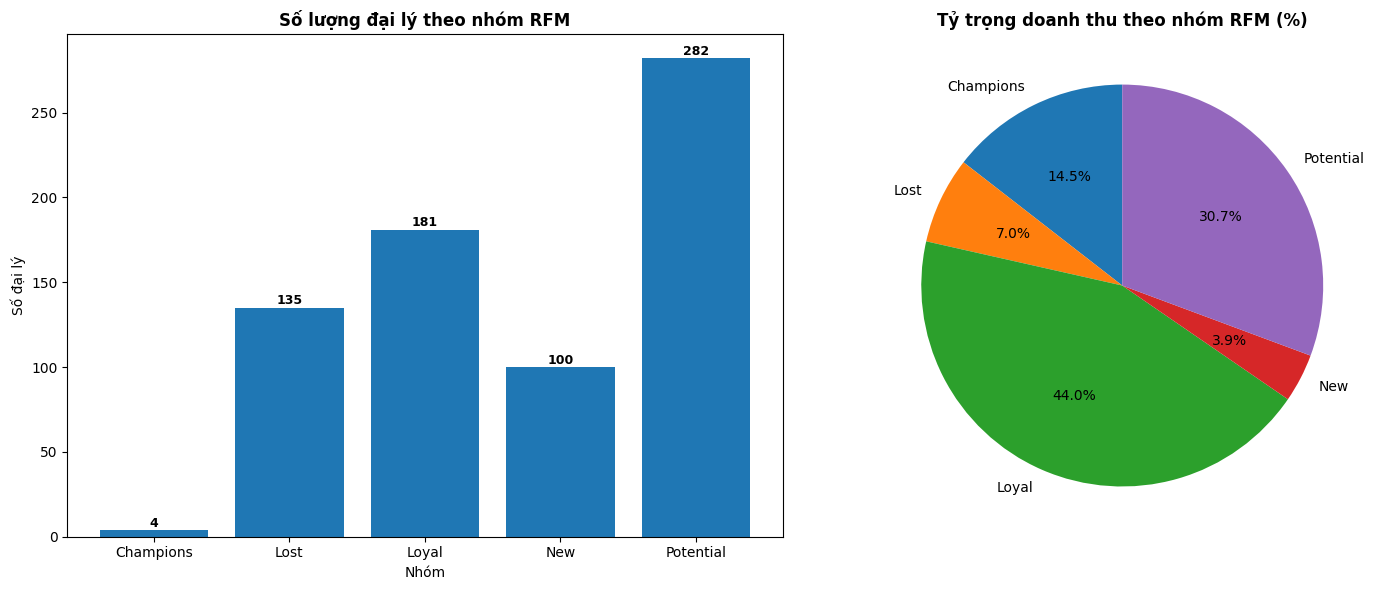

  segment  count  rev_%
Champions      4   14.5
     Lost    135    7.0
    Loyal    181   44.0
      New    100    3.9
Potential    282   30.7


In [6]:
seg_revenue = rfm.merge(
    df.groupby('customer_code')['line_total'].sum().reset_index(),
    on='customer_code', how='left'
).groupby('segment').agg(
    count=('customer_code','count'),
    revenue=('line_total','sum')
).reset_index()
seg_revenue['rev_share'] = seg_revenue['revenue'] / seg_revenue['revenue'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(seg_revenue['segment'], seg_revenue['count'])
for i, row in seg_revenue.iterrows():
    axes[0].text(i, row['count'] + 2, str(row['count']), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Số lượng đại lý theo nhóm RFM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nhóm')
axes[0].set_ylabel('Số đại lý')

axes[1].pie(seg_revenue['rev_share'], labels=seg_revenue['segment'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ trọng doanh thu theo nhóm RFM (%)', fontsize=12, fontweight='bold')

fig.tight_layout()
plt.show()
print(seg_revenue[['segment','count','rev_share']].rename(columns={'rev_share':'rev_%'}).round(1).to_string(index=False))

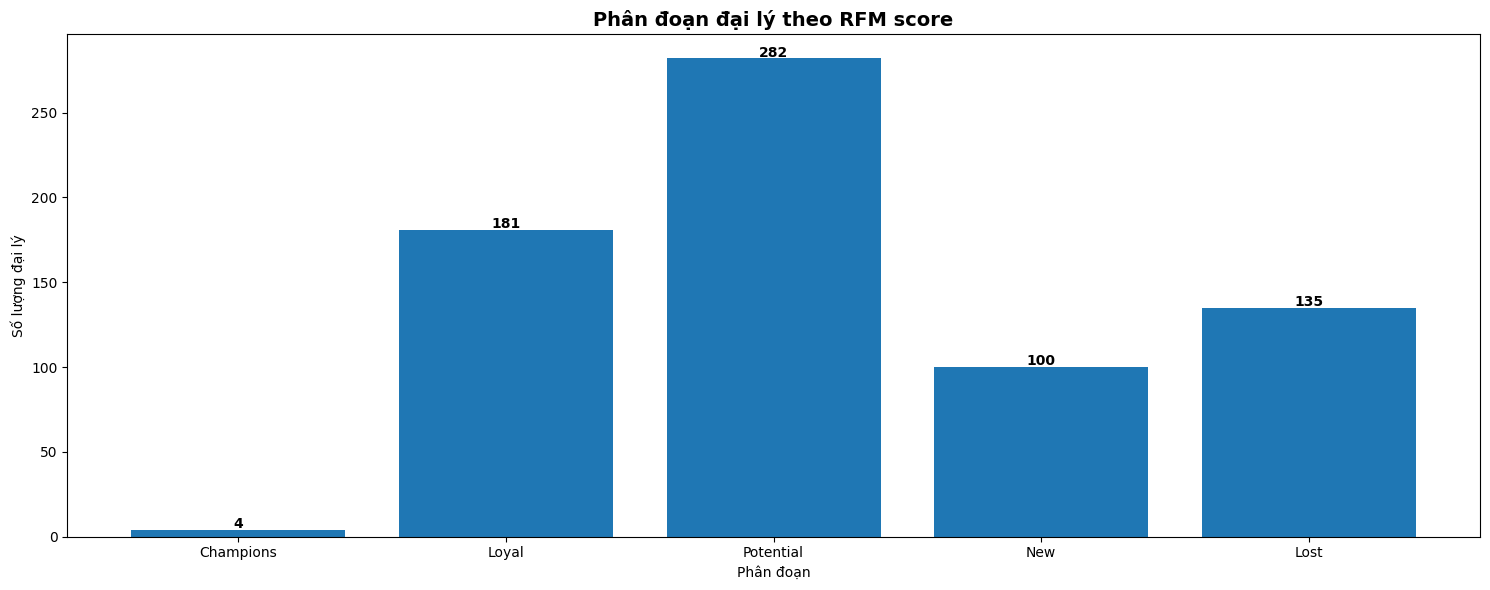

In [7]:
seg_order = ['Champions','Loyal','Potential','New','At-Risk','Lost']
seg_plot  = seg_counts.reindex([s for s in seg_order if s in seg_counts.index])

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(seg_plot.index, seg_plot.values)
for i, (seg, val) in enumerate(seg_plot.items()):
    ax.text(i, val + 1, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Phân đoạn đại lý theo RFM score', fontsize=14, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Số lượng đại lý')
fig.tight_layout()
plt.show()

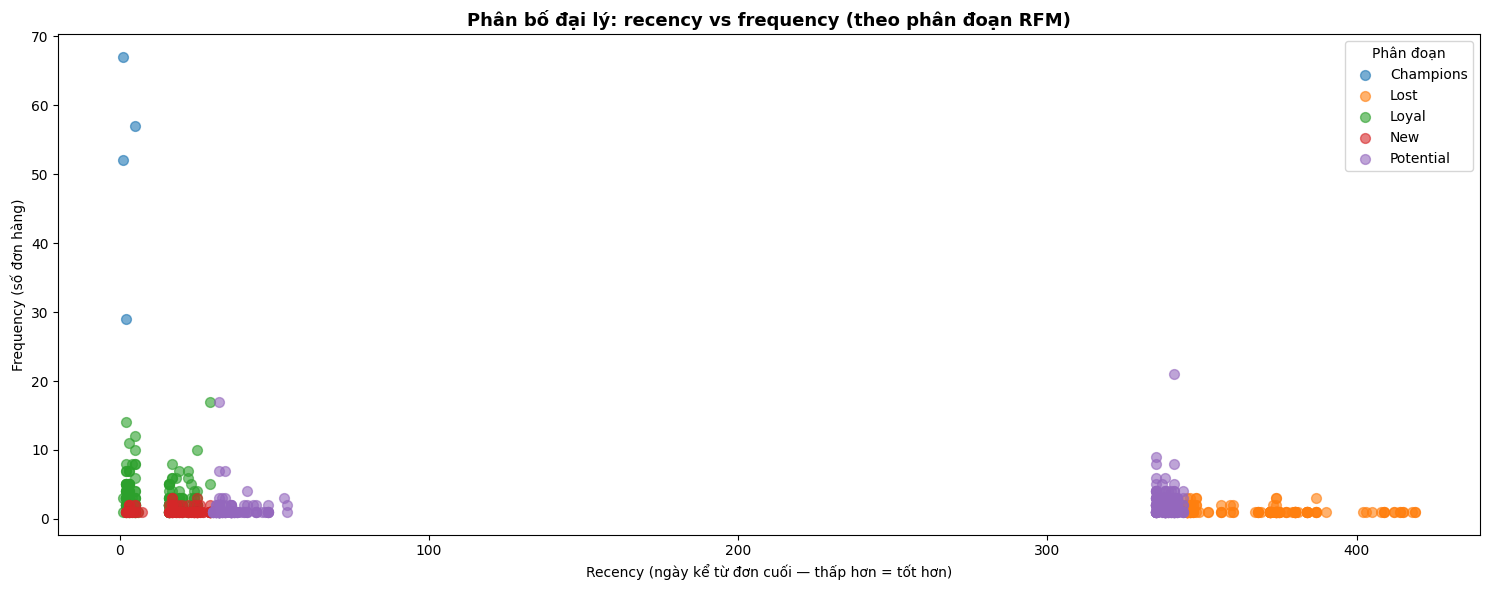

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
for seg, grp in rfm.groupby('segment'):
    ax.scatter(grp['recency'], grp['frequency'], alpha=0.6, label=seg, s=50)
ax.set_title('Phân bố đại lý: recency vs frequency (theo phân đoạn RFM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recency (ngày kể từ đơn cuối — thấp hơn = tốt hơn)')
ax.set_ylabel('Frequency (số đơn hàng)')
ax.legend(title='Phân đoạn')
fig.tight_layout()
plt.show()

In [9]:
df_train_lr = df[df['year_month'].astype(str) < '2026-01']
df_test_lr  = df[df['year_month'].astype(str) == '2026-01']

def compute_rfm(data, ref_date_str):
    ref = pd.Timestamp(ref_date_str)
    return data.groupby('customer_code').agg(
        recency   =('order_date',  lambda x: (ref - x.max()).days),
        frequency =('so_number',   'nunique'),
        monetary  =('line_total',  'sum')
    ).reset_index()

rfm_train = compute_rfm(df_train_lr, '2026-01-01')
jan_buyers = set(df_test_lr['customer_code'].unique())
rfm_train['churn_label'] = (~rfm_train['customer_code'].isin(jan_buyers)).astype(int)

rfm_test = compute_rfm(df[df['year_month'].astype(str) <= '2026-01'], '2026-02-01')
feb_buyers = set(df[df['year_month'].astype(str) == '2026-02']['customer_code'].unique())
rfm_test['churn_label'] = (~rfm_test['customer_code'].isin(feb_buyers)).astype(int)

print(f'Train: {len(rfm_train)} đại lý | Tỉ lệ churn: {rfm_train["churn_label"].mean():.1%}')
print(f'Test : {len(rfm_test)}  đại lý | Tỉ lệ churn: {rfm_test["churn_label"].mean():.1%}')

Train: 333 đại lý | Tỉ lệ churn: 89.5%
Test : 588  đại lý | Tỉ lệ churn: 73.8%


In [10]:
feat_cols = ['recency', 'frequency', 'monetary']

X_train = rfm_train[feat_cols].fillna(0).values
y_train = rfm_train['churn_label'].values
X_test  = rfm_test[feat_cols].fillna(0).values
y_test  = rfm_test['churn_label'].values

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
log_reg.fit(X_train_s, y_train)

y_pred       = log_reg.predict(X_test_s)
y_prob_churn = log_reg.predict_proba(X_test_s)[:, 0]

print('=== Logistic regression — out-of-sample test (tháng 2/2026) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred, zero_division=0,
      target_names=['Ở lại (0)','Rời bỏ (1)']))

=== Logistic regression — out-of-sample test (tháng 2/2026) ===
Accuracy : 0.490
Precision: 0.661
Recall   : 0.634

Classification report:
              precision    recall  f1-score   support

   Ở lại (0)       0.08      0.08      0.08       154
  Rời bỏ (1)       0.66      0.63      0.65       434

    accuracy                           0.49       588
   macro avg       0.37      0.36      0.36       588
weighted avg       0.51      0.49      0.50       588



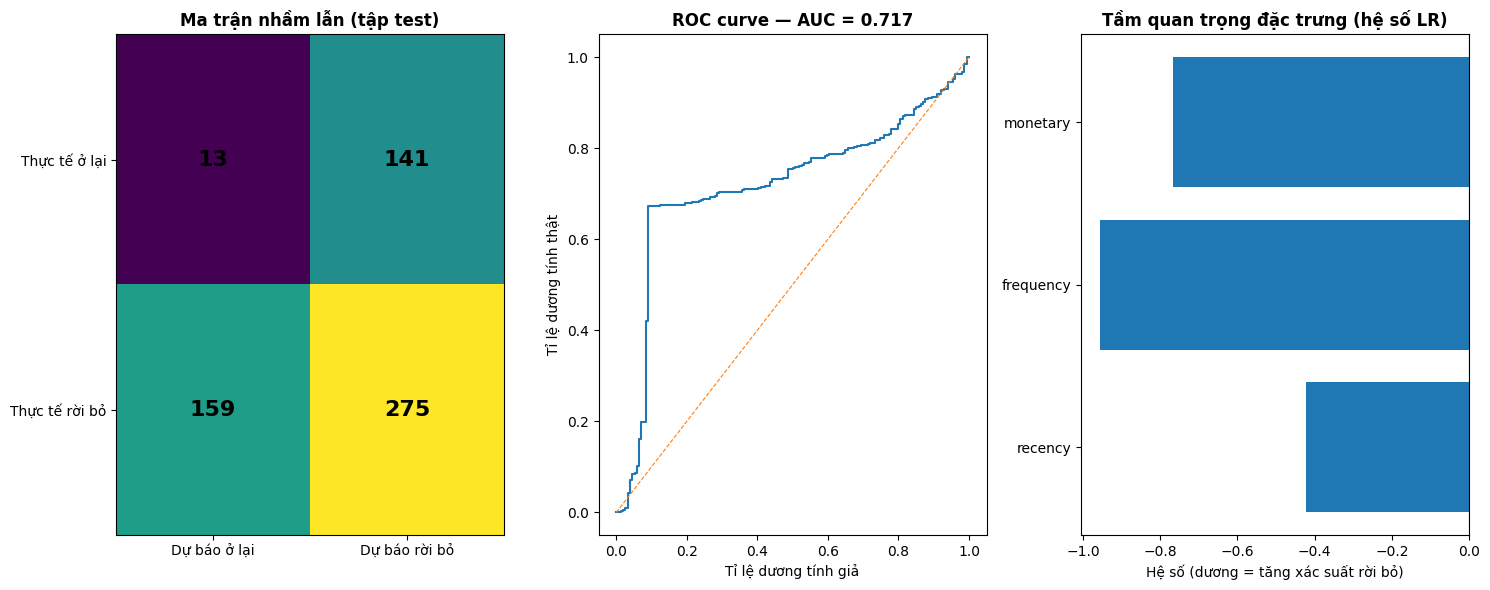

ROC-AUC score trên tập test: 0.7171


In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(cm, aspect='auto')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16, fontweight='bold')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Dự báo ở lại','Dự báo rời bỏ'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Thực tế ở lại','Thực tế rời bỏ'])
axes[0].set_title('Ma trận nhầm lẫn (tập test)', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_churn)
auc_score   = roc_auc_score(y_test, y_prob_churn)
axes[1].plot(fpr, tpr)
axes[1].plot([0,1],[0,1], linestyle='--', linewidth=0.8)
axes[1].set_title(f'ROC curve — AUC = {auc_score:.3f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tỉ lệ dương tính giả')
axes[1].set_ylabel('Tỉ lệ dương tính thật')

coefs = log_reg.coef_[0]
axes[2].barh(feat_cols, coefs)
axes[2].axvline(0, linewidth=0.8)
axes[2].set_title('Tầm quan trọng đặc trưng (hệ số LR)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hệ số (dương = tăng xác suất rời bỏ)')

fig.tight_layout()
plt.show()
print(f'ROC-AUC score trên tập test: {auc_score:.4f}')

In [12]:
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data

    bgf_data = summary_data_from_transaction_data(
        df, customer_id_col='customer_code',
        datetime_col='order_date',
        monetary_value_col='line_total',
        observation_period_end=pd.Timestamp('2026-02-28'),
        freq='D'
    )
    bgf = BetaGeoFitter(penalizer_coef=0.001)
    bgf.fit(bgf_data['frequency'], bgf_data['recency'], bgf_data['T'])
    bgf_data['pred_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        90, bgf_data['frequency'], bgf_data['recency'], bgf_data['T']
    )

    gg_data = bgf_data[bgf_data['monetary_value'] > 0].copy()
    ggf = GammaGammaFitter(penalizer_coef=0.001)
    ggf.fit(gg_data['frequency'], gg_data['monetary_value'])
    gg_data['expected_avg_revenue'] = ggf.conditional_expected_average_profit(
        gg_data['frequency'], gg_data['monetary_value']
    )
    bgf_data = bgf_data.join(gg_data[['expected_avg_revenue']], how='left')
    bgf_data['CLV_90d'] = bgf_data['pred_purchases_90d'] * bgf_data['expected_avg_revenue'].fillna(0)

    print('BG-NBD + Gamma-Gamma CLV computed successfully!')
    print(f'Trung bình dự báo số đơn 90 ngày tới: {bgf_data["pred_purchases_90d"].mean():.2f}')
    print(bgf_data[['frequency','recency','T','pred_purchases_90d','CLV_90d']].head().round(2))
    BG_NBD_OK = True
except ImportError:
    print('[INFO] lifetimes không khả dụng — bỏ qua BG-NBD. Dùng RFM + LogReg.')
    BG_NBD_OK = False
    bgf_data = None
except Exception as e:
    print(f'[WARNING] BG-NBD lỗi: {e} — fallback to RFM scoring.')
    BG_NBD_OK = False
    bgf_data = None

BG-NBD + Gamma-Gamma CLV computed successfully!
Trung bình dự báo số đơn 90 ngày tới: 0.59
               frequency  recency      T  pred_purchases_90d      CLV_90d
customer_code                                                            
KH-00001             2.0     83.0  422.0                0.04    189220.31
KH-00002             0.0      0.0  418.0                0.05         0.00
KH-00003             0.0      0.0  418.0                0.05         0.00
KH-00004             8.0    414.0  418.0                1.49  49571472.40
KH-00005             0.0      0.0  417.0                0.05         0.00


In [13]:
rfm_q2 = df.groupby('customer_code').agg(
    recency   =('order_date',  lambda x: (pd.Timestamp('2026-03-01') - x.max()).days),
    frequency =('so_number',   'nunique'),
    monetary  =('line_total',  'sum')
).reset_index()

X_q2_s = scaler.transform(rfm_q2[feat_cols].fillna(0).values)
rfm_q2['churn_prob'] = log_reg.predict_proba(X_q2_s)[:, 0]

rfm_q2 = rfm_q2.merge(rfm[['customer_code','segment','customer_name']], on='customer_code', how='left')

print('Phân phối xác suất churn Q2/2026:')
print(rfm_q2['churn_prob'].describe().round(3))
print(f"\nĐại lý churn cao (>0.6): {(rfm_q2['churn_prob']>0.6).sum()}")
print(f"Đại lý churn thấp (<0.4): {(rfm_q2['churn_prob']<0.4).sum()}")

Phân phối xác suất churn Q2/2026:
count    702.000
mean       0.280
std        0.327
min        0.001
25%        0.002
50%        0.008
75%        0.621
max        1.000
Name: churn_prob, dtype: float64

Đại lý churn cao (>0.6): 191
Đại lý churn thấp (<0.4): 407


In [14]:
action_list = (
    rfm_q2[rfm_q2['churn_prob'] > 0.6]
    .sort_values('monetary', ascending=False)
    .head(20)
    [['customer_code','customer_name','segment','monetary','churn_prob']]
    .rename(columns={
        'customer_code': 'Mã_Đại_Lý',
        'customer_name': 'Tên_Đại_Lý',
        'segment'      : 'Nhóm_RFM',
        'monetary'     : 'Doanh_Thu',
        'churn_prob'   : 'Xác_Suất_Rời_Bỏ',
    })
)
action_list['Doanh_Thu'] = (action_list['Doanh_Thu'] / 1e9).round(2)

print('=== Top 20 đại lý ưu tiên chăm sóc (doanh thu cao + churn > 60%) ===')
print(action_list.to_string(index=False))

action_list.to_csv('../data/sales_action_list_Q2.csv', index=False, encoding='utf-8-sig')
print(f'\n→ Đã xuất: data/sales_action_list_Q2.csv ({len(action_list)} đại lý)')

=== Top 20 đại lý ưu tiên chăm sóc (doanh thu cao + churn > 60%) ===
Mã_Đại_Lý                            Tên_Đại_Lý  Nhóm_RFM  Doanh_Thu  Xác_Suất_Rời_Bỏ
 KH-00091                CÔNG TY TNHH BÌNH MINH Champions       4.98         1.000000
 KH-00019     CÔNG TY CỔ PHẦN THƯƠNG MẠI LÊ ANH Champions       3.62         1.000000
 KH-00173             DOANH NGHIỆP TW PHÚ THỊNH Potential       1.58         0.999999
 KH-00006                CÔNG TY TNHH CHI THÀNH Champions       1.09         1.000000
 KH-00338       CÔNG TY TNHH THƯƠNG MẠI ĐẠI LỢI     Loyal       0.60         0.675686
 KH-00057 CÔNG TY CỔ PHẦN THƯƠNG MẠI TOÀN THẮNG Potential       0.56         0.973908
 KH-00065            CÔNG TY CỔ PHẦN QUANG VINH Potential       0.55         0.992251
 KH-00064                   CÔNG TY TNHH SƠN HÀ Potential       0.36         0.963309
 KH-00132      CÔNG TY TNHH THƯƠNG MẠI HOÀ BÌNH Potential       0.34         0.915514
 KH-00098                HỘ KINH DOANH MẶT TRỜI      Lost       0.30   

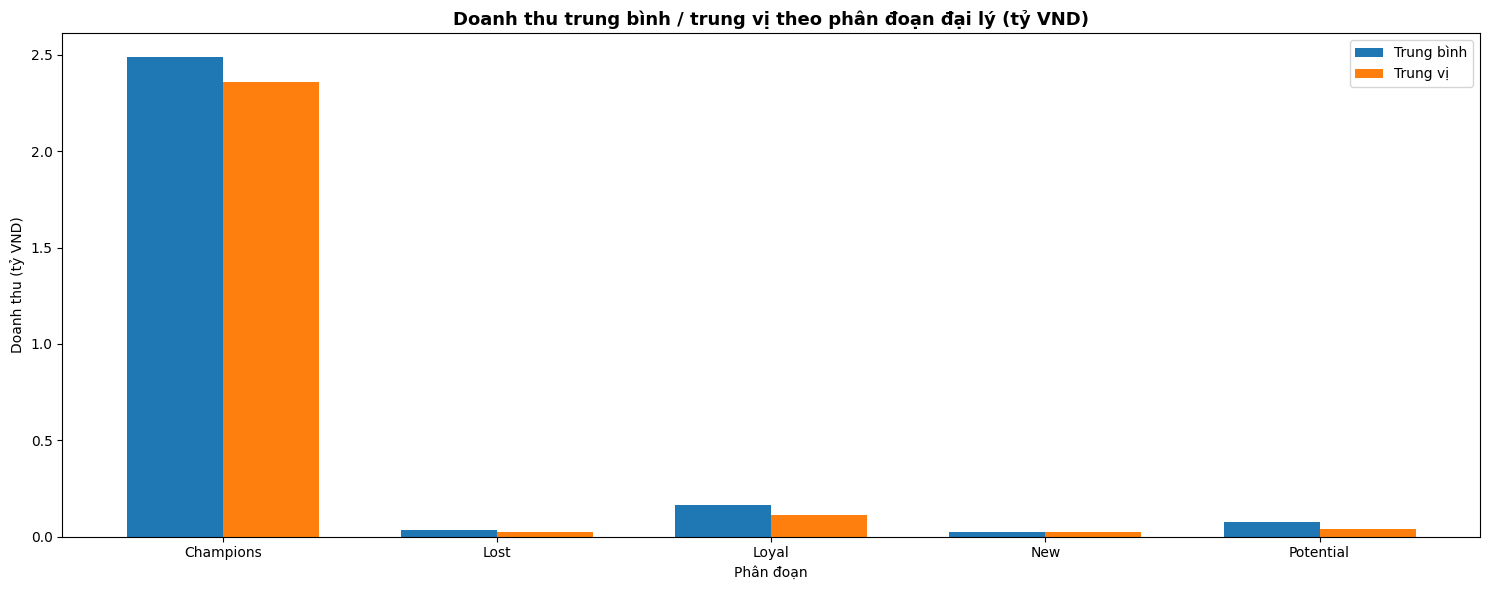

In [15]:
seg_monetary = (
    rfm_q2.groupby('segment')['monetary']
    .agg(['mean','median'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(seg_monetary))
w = 0.35
ax.bar(x - w/2, seg_monetary['mean']   / 1e9, width=w, label='Trung bình')
ax.bar(x + w/2, seg_monetary['median'] / 1e9, width=w, label='Trung vị')
ax.set_xticks(x)
ax.set_xticklabels(seg_monetary['segment'])
ax.set_title('Doanh thu trung bình / trung vị theo phân đoạn đại lý (tỷ VND)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.legend()
fig.tight_layout()
plt.show()

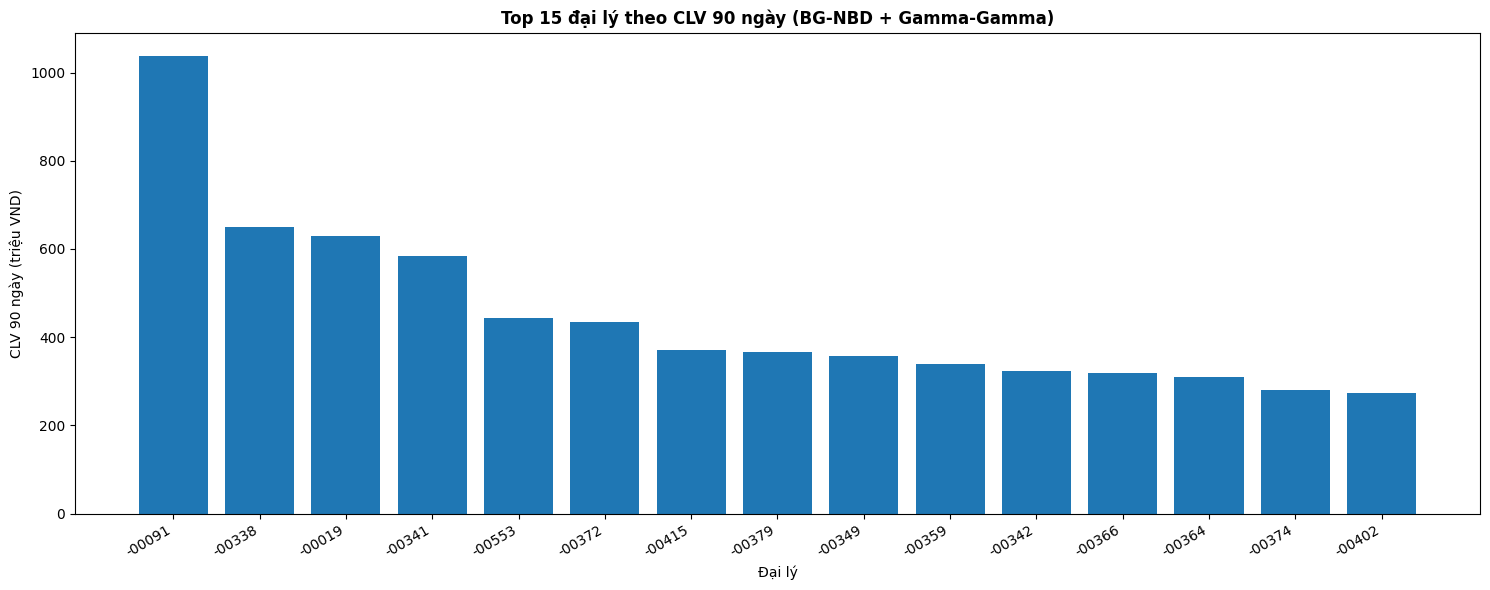

In [16]:
if BG_NBD_OK and bgf_data is not None:
    top_clv = bgf_data.sort_values('CLV_90d', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(top_clv)), top_clv['CLV_90d'] / 1e6)
    ax.set_xticks(range(len(top_clv)))
    ax.set_xticklabels(top_clv.index.str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 đại lý theo CLV 90 ngày (BG-NBD + Gamma-Gamma)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('CLV 90 ngày (triệu VND)')
    fig.tight_layout()
    plt.show()
else:
    rfm_proxy = rfm.sort_values('RFM_total', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(rfm_proxy)), rfm_proxy['RFM_total'])
    ax.set_xticks(range(len(rfm_proxy)))
    ax.set_xticklabels(rfm_proxy['customer_code'].str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 đại lý theo RFM total score (proxy CLV)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('RFM score (3–15)')
    fig.tight_layout()
    plt.show()

## Kết luận Q3: phân tích hoạt động đại lý

Phân tích RFM cho thấy phần lớn đại lý thuộc nhóm Potential và Loyal, trong khi nhóm Champions chỉ có rất ít đại lý nhưng đóng góp tỷ trọng doanh thu đáng kể. Nhóm Lost cần chiến dịch win-back còn nhóm At-Risk cần tái kích hoạt sớm.

Mô hình Logistic Regression với phân tách theo thời gian cho thấy recency là yếu tố dự báo churn quan trọng nhất. Chỉ số AUC phản ánh đặc thù B2B với chu kỳ mua hàng không đều và phụ thuộc mùa vụ.

Khuyến nghị cho ban giám đốc: ưu tiên chăm sóc 20 đại lý doanh thu cao có xác suất churn trên 60% (đã xuất file `sales_action_list_Q2.csv`), triển khai chương trình loyalty cho nhóm Champions, và theo dõi CLV thực tế Q2/2026 để kiểm chứng dự báo.